In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

#loading reqs
from config import *
from utils_old import *


In [2]:
# Debug script to find differences between old and new models

import pandas as pd
import numpy as np

# Run this in both your old and new model notebooks to compare

def debug_model_state():
    """
    Add this function to both models and call it right before running the coral model
    to check if all parameters are identical
    """
    
    print("=== MODEL STATE DEBUG ===")
    
    # Check key variables that might differ
    print(f"PSD_T0 shape: {PSD_T0.shape if 'PSD_T0' in globals() else 'NOT DEFINED'}")
    print(f"MaxYear: {MaxYear if 'MaxYear' in globals() else 'NOT DEFINED'}")
    print(f"binSize: {binSize if 'binSize' in globals() else 'NOT DEFINED'}")
    print(f"MaxBinId: {MaxBinId if 'MaxBinId' in globals() else 'NOT DEFINED'}")
    print(f"reef_area: {reef_area if 'reef_area' in globals() else 'NOT DEFINED'}")
    
    # Check if PSD_T0 data is identical
    if 'PSD_T0' in globals():
        print(f"PSD_T0 first few rows:")
        print(PSD_T0.head())
        print(f"PSD_T0 sum: {PSD_T0.sum().sum()}")
    
    # Check opts object state
    if 'opts' in globals():
        print(f"opts.dhw_lst: {getattr(opts, 'dhw_lst', 'NOT DEFINED')}")
        print(f"opts.cyc_lst: {getattr(opts, 'cyc_lst', 'NOT DEFINED')}")
    
    # Check random state
    print(f"Random state: {np.random.get_state()[1][0]}")
    
    print("========================")

# Call this function right before your model loop in both versions:
# debug_model_state()

def compare_single_iteration():
    """
    Run just ONE iteration of each model with the same seed and compare
    """
    
    # Set identical seeds
    np.random.seed(42)
    import random
    random.seed(42)
    
    print("Running single iteration comparison...")
    
    # Run one iteration
    coral_model_results = run_coral_model(PSD_T0, MaxYear)
    
    print("Single iteration results:")
    print(coral_model_results.head())
    print(f"Results sum: {coral_model_results.sum().sum()}")
    
    return coral_model_results

# Additional checks to add to your models:

def check_function_definitions():
    """
    Check if key functions are defined identically
    """
    import inspect
    
    functions_to_check = [
        'run_coral_model', 
        'run_yearly_change', 
        'initialize_coral',
        'calculate_population_change',
        'get_PCM_rates_after_dhw',
        'get_WCM_rates_after_cyclones'
    ]
    
    for func_name in functions_to_check:
        if func_name in globals():
            func = globals()[func_name]
            source = inspect.getsource(func)
            print(f"\n{func_name} source hash: {hash(source)}")
        else:
            print(f"{func_name}: NOT DEFINED")

# Instructions:
print("""
DEBUG INSTRUCTIONS:

1. Add debug_model_state() call right before your model loop in BOTH notebooks
2. Run compare_single_iteration() in both notebooks with same seed
3. Run check_function_definitions() in both notebooks
4. Compare all outputs between old and new models

Look for differences in:
- Parameter values (PSD_T0, MaxYear, etc.)
- Function source code hashes
- Single iteration results
- Random state initialization
""")


DEBUG INSTRUCTIONS:

1. Add debug_model_state() call right before your model loop in BOTH notebooks
2. Run compare_single_iteration() in both notebooks with same seed
3. Run check_function_definitions() in both notebooks
4. Compare all outputs between old and new models

Look for differences in:
- Parameter values (PSD_T0, MaxYear, etc.)
- Function source code hashes
- Single iteration results
- Random state initialization



=== MODEL STATE DEBUG ===
PSD_T0 shape: (20, 4)
MaxYear: 11
binSize: 5
MaxBinId: 20
reef_area: 10000
PSD_T0 first few rows:
   Bins  Branching  Foliose  Other
0     5        1.0      2.8   18.8
1    10        8.5     13.3   25.3
2    15       11.5     14.2   19.7
3    20       10.2      7.6    4.7
4    25        9.3      7.0    4.3
PSD_T0 sum: 1349.6
opts.dhw_lst: NOT DEFINED
opts.cyc_lst: NOT DEFINED
Random state: 42
Running single iteration comparison...
Single iteration results:
   Year  Branching_Area (%)  Foliose_Area (%)  Other_Area (%)  \
0     0            1.200000          2.200000       16.300000   
1     1            1.299475          2.311972       16.666005   
2     2            1.552621          2.464432       17.539458   
3     3            2.107498          2.671304       18.270329   
4     4            3.069053          2.947292       19.598835   

   total_coral_cover (%)  
0              19.700000  
1              20.277453  
2              21.556511  
3             

NameError: name 'output_dir' is not defined

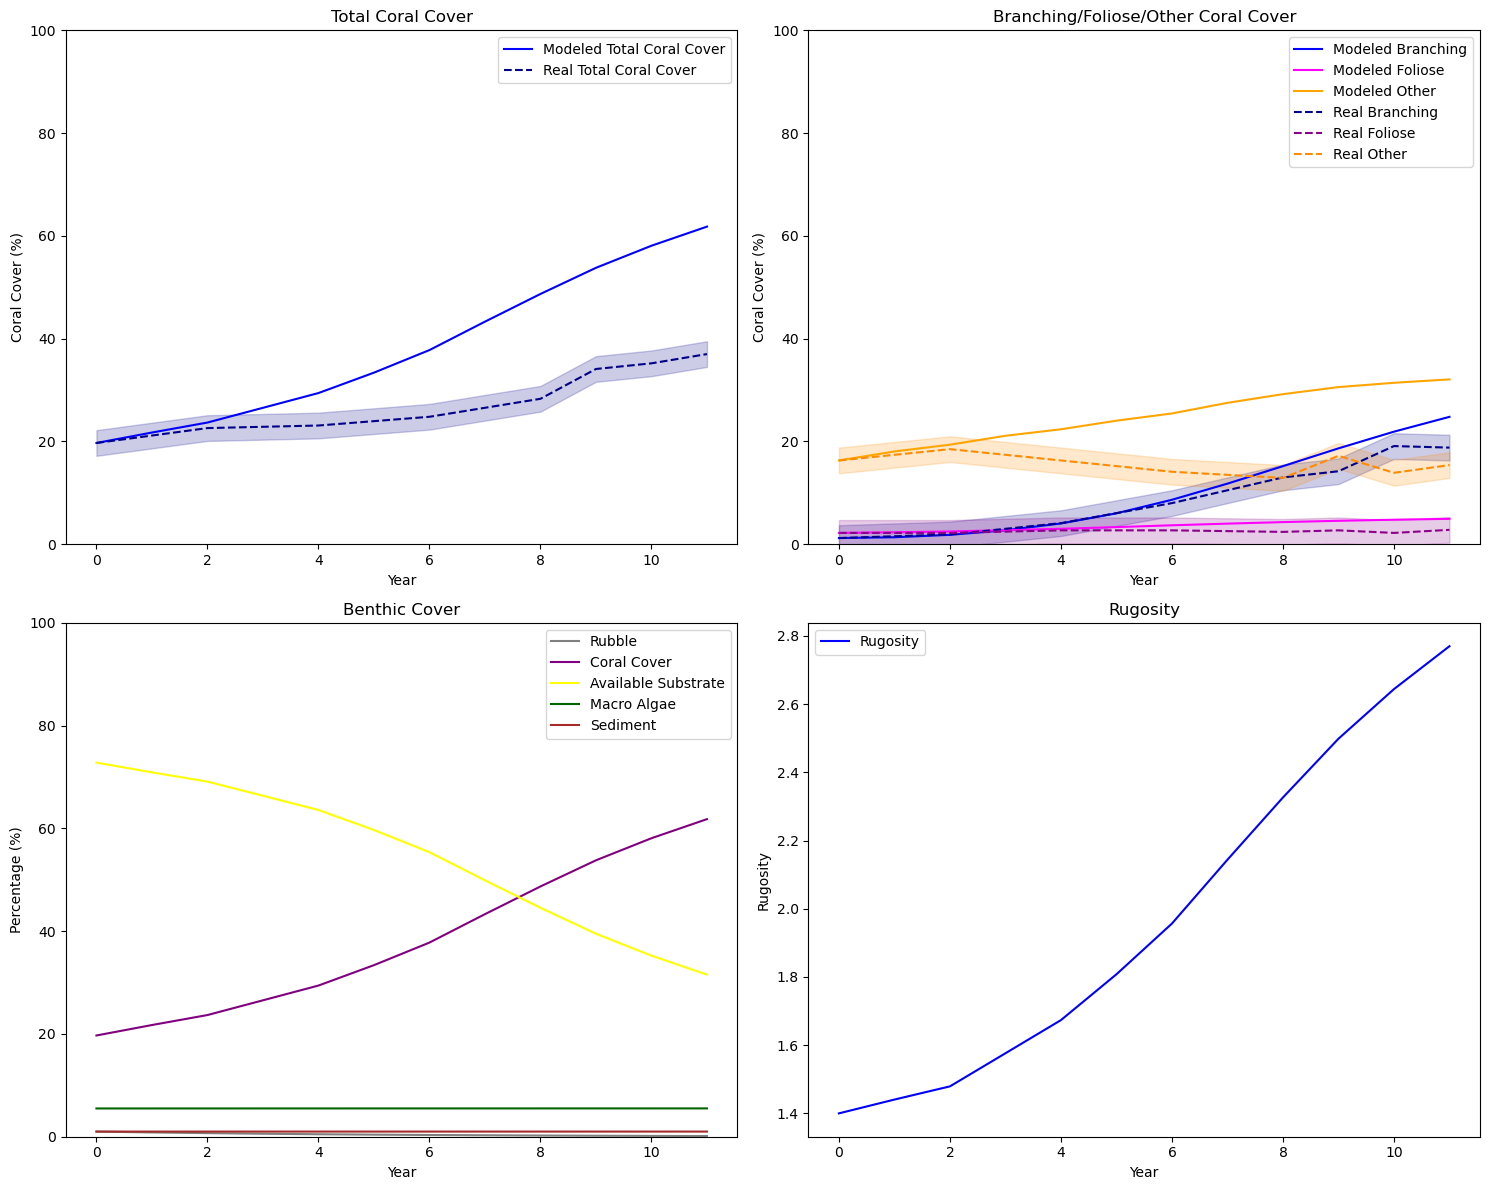

In [3]:

import numpy as np
import random
np.random.seed(42)
random.seed(42)

debug_model_state() 
compare_single_iteration()
check_function_definitions()

# Real data input from Overview of modelling data_2024 
#My real data
real_data = {
    'Year': [0,1,2,3,4,5,6,7,8,9,10,11],#start year + number of years model run for
    'RealBranching_Area (%)': [1.2,1.55,1.9,3,4.1,6.05,8,10.5,13,14.2,19.1,18.8],
    'RealFoliose_Area (%)': [2.2,2.2,2.2,2.45,2.7,2.7,2.7,2.55,2.4,2.7,2.2,2.8],
    'RealOther_Area (%)': [16.3,17.4,18.5,17.4,16.3,15.2,14.1,13.5,12.9,17.2,13.9,15.4] 
}
real_df = pd.DataFrame(real_data)

# Function to run the model 100 times and collect the results
def run_model_100_times():
    population_results = []
    percentage_population_results = []
    area_results = []
    final_results = []
    
    for _ in range(1):
        coral_model_results = run_coral_model(PSD_T0, MaxYear)
        benthic_cover_results = opts.yearly_benthic_cover_df
        rugosity_results = get_rugosity_list()
        
        # Merge the results into a single DataFrame
        merged_results = pd.merge(coral_model_results, benthic_cover_results, on='Year')
        merged_results['Rugosity'] = rugosity_results
        
        final_results.append(merged_results)
        
        # Collect population, percentage population, and area results
        for year in range(MaxYear + 1):
            population_df = opts.yearly_population_df_list[year]
            surface_area_df = opts.yearly_surface_area_df_list[year]
            
            for mg in ['Branching', 'Foliose', 'Other']:
                # Population Size DataFrame
                pop_size_row = [mg, year] + population_df[mg].tolist()
                population_results.append(pop_size_row)
                
                # Percentage Population Size DataFrame
                total_pop = population_df[mg].sum()
                perc_pop_size_row = [mg, year] + (100 * population_df[mg] / total_pop).tolist()
                percentage_population_results.append(perc_pop_size_row)
                
                # Area DataFrame
                total_area = reef_area  # Total area in m²
                perc_area_row = [mg, year] + (100 * surface_area_df[mg] / total_area).tolist()
                area_results.append(perc_area_row)
    
    # Concatenate all the results into a single DataFrame
    final_df = pd.concat(final_results)
    
    return final_df, population_results, percentage_population_results, area_results

# Run the model 100 times and get the results
final_df, population_results, percentage_population_results, area_results = run_model_100_times()

# Create dataframes for population size, percentage population size, and area
bin_diameters = [i * binSize for i in range(MaxBinId)]
columns = ['MG', 'Year'] + [f'Bin Diameter {d} (cm)' for d in bin_diameters]

population_size_df = pd.DataFrame(population_results, columns=columns)
percentage_population_size_df = pd.DataFrame(percentage_population_results, columns=columns)
area_df = pd.DataFrame(area_results, columns=columns)

# Print the dataframes
print("Final DataFrame")
print(final_df)

#print("\nPopulation Size DataFrame")
#print(population_size_df)

#print("\nPercentage Population Size DataFrame")
#print(percentage_population_size_df)

#print("\nArea DataFrame")
#print(area_df)




# Assuming final_df and real_df are already defined DataFrames
# Calculate the total coral cover for modeled data
final_df['Total_Coral_Cover (%)'] = final_df['Branching_Area (%)'] + final_df['Foliose_Area (%)'] + final_df['Other_Area (%)']

# Calculate the total coral cover for real data
real_df['Total_Coral_Cover (%)'] = real_df['RealBranching_Area (%)'] + real_df['RealFoliose_Area (%)'] + real_df['RealOther_Area (%)']

# Calculate the average and standard deviation for each morphology
average_branching = final_df.groupby('Year')['Branching_Area (%)'].mean()
std_dev_branching = final_df.groupby('Year')['Branching_Area (%)'].std()

average_foliose = final_df.groupby('Year')['Foliose_Area (%)'].mean()
std_dev_foliose = final_df.groupby('Year')['Foliose_Area (%)'].std()

average_other = final_df.groupby('Year')['Other_Area (%)'].mean()
std_dev_other = final_df.groupby('Year')['Other_Area (%)'].std()

average_total = final_df.groupby('Year')['Total_Coral_Cover (%)'].mean()
std_dev_total = final_df.groupby('Year')['Total_Coral_Cover (%)'].std()

# Calculate the margins for real data (5% absolute above and below)
absolute_margin = 2.5

real_branching_margin = absolute_margin
real_foliose_margin = absolute_margin
real_other_margin = absolute_margin
real_total_margin = absolute_margin

# Create a figure with 2x2 subplots
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

years = average_branching.index

# Plot Total Coral Cover
axs[0, 0].plot(years, average_total, label='Modeled Total Coral Cover', color='blue')
axs[0, 0].fill_between(years, average_total - std_dev_total, average_total + std_dev_total, color='blue', alpha=0.2)
axs[0, 0].plot(real_df['Year'], real_df['Total_Coral_Cover (%)'], label='Real Total Coral Cover', color='darkblue', linestyle='--')
axs[0, 0].fill_between(real_df['Year'], real_df['Total_Coral_Cover (%)'] - real_total_margin, real_df['Total_Coral_Cover (%)'] + real_total_margin, color='darkblue', alpha=0.2)
axs[0, 0].set_title('Total Coral Cover')
axs[0, 0].set_xlabel('Year')
axs[0, 0].set_ylabel('Coral Cover (%)')
axs[0, 0].legend()
axs[0, 0].set_ylim(0, 100)  # Set y-axis limits from 0 to 100
axs[0, 0].set_yticks(range(0, 101, 20))  # Set y-axis ticks at 0, 20, 40, 60, 80, 100


# Plot Branching, Foliose, and Other Coral Cover
axs[0, 1].plot(years, average_branching, label='Modeled Branching', color='blue')
axs[0, 1].fill_between(years, average_branching - std_dev_branching, average_branching + std_dev_branching, color='blue', alpha=0.2)
axs[0, 1].plot(years, average_foliose, label='Modeled Foliose', color='fuchsia')
axs[0, 1].fill_between(years, average_foliose - std_dev_foliose, average_foliose + std_dev_foliose, color='fuchsia', alpha=0.2)
axs[0, 1].plot(years, average_other, label='Modeled Other', color='orange')
axs[0, 1].fill_between(years, average_other - std_dev_other, average_other + std_dev_other, color='orange', alpha=0.2)
axs[0, 1].plot(real_df['Year'], real_df['RealBranching_Area (%)'], label='Real Branching', color='darkblue', linestyle='--')
axs[0, 1].fill_between(real_df['Year'], real_df['RealBranching_Area (%)'] - real_branching_margin, real_df['RealBranching_Area (%)'] + real_branching_margin, color='darkblue', alpha=0.2)
axs[0, 1].plot(real_df['Year'], real_df['RealFoliose_Area (%)'], label='Real Foliose', color='darkmagenta', linestyle='--')
axs[0, 1].fill_between(real_df['Year'], real_df['RealFoliose_Area (%)'] - real_foliose_margin, real_df['RealFoliose_Area (%)'] + real_foliose_margin, color='darkmagenta', alpha=0.2)
axs[0, 1].plot(real_df['Year'], real_df['RealOther_Area (%)'], label='Real Other', color='darkorange', linestyle='--')
axs[0, 1].fill_between(real_df['Year'], real_df['RealOther_Area (%)'] - real_other_margin, real_df['RealOther_Area (%)'] + real_other_margin, color='darkorange', alpha=0.2)
axs[0, 1].set_title('Branching/Foliose/Other Coral Cover')
axs[0, 1].set_xlabel('Year')
axs[0, 1].set_ylabel('Coral Cover (%)')
axs[0, 1].legend()
axs[0, 1].set_ylim(0, 100)  # Set y-axis limits from 0 to 100
axs[0, 1].set_yticks(range(0, 101, 20))  # Set y-axis ticks at 0, 20, 40, 60, 80, 100


# Plot Benthic Cover
average_rubble = final_df.groupby('Year')['rubble (%)'].mean()
std_dev_rubble = final_df.groupby('Year')['rubble (%)'].std()
average_coral_cover = final_df.groupby('Year')['total_coral_cover (%)'].mean()
std_dev_coral_cover = final_df.groupby('Year')['total_coral_cover (%)'].std()
average_as = final_df.groupby('Year')['available_substrate (%)'].mean()
std_dev_as = final_df.groupby('Year')['available_substrate (%)'].std()
average_ma = final_df.groupby('Year')['macro_algae (%)'].mean()
std_dev_ma = final_df.groupby('Year')['macro_algae (%)'].std()
average_sediment = final_df.groupby('Year')['sediment (%)'].mean()
std_dev_sediment = final_df.groupby('Year')['sediment (%)'].std()

years_benthic = average_rubble.index

axs[1, 0].plot(years_benthic, average_rubble, label='Rubble', color='grey')
axs[1, 0].fill_between(years_benthic, average_rubble - std_dev_rubble, average_rubble + std_dev_rubble, color='grey', alpha=0.2)
axs[1, 0].plot(years_benthic, average_coral_cover, label='Coral Cover', color='purple')
axs[1, 0].fill_between(years_benthic, average_coral_cover - std_dev_coral_cover, average_coral_cover + std_dev_coral_cover, color='purple', alpha=0.2)
axs[1, 0].plot(years_benthic, average_as, label='Available Substrate', color='yellow')
axs[1, 0].fill_between(years_benthic, average_as - std_dev_as, average_as + std_dev_as, color='yellow', alpha=0.2)
axs[1, 0].plot(years_benthic, average_ma, label='Macro Algae', color='darkgreen')
axs[1, 0].fill_between(years_benthic, average_ma - std_dev_ma, average_ma + std_dev_ma, color='darkgreen', alpha=0.2)
axs[1, 0].plot(years_benthic, average_sediment, label='Sediment', color='brown')
axs[1, 0].fill_between(years_benthic, average_sediment - std_dev_sediment, average_sediment + std_dev_sediment, color='brown', alpha=0.2)
axs[1, 0].set_title('Benthic Cover')
axs[1, 0].set_xlabel('Year')
axs[1, 0].set_ylabel('Percentage (%)')
axs[1, 0].legend()
axs[1, 0].set_ylim(0, 100)  # Set y-axis limits from 0 to 100
axs[1, 0].set_yticks(range(0, 101, 20))  # Set y-axis ticks at 0, 20, 40, 60, 80, 100


# Plot Rugosity
average_rugosity = final_df.groupby('Year')['Rugosity'].mean()
std_dev_rugosity = final_df.groupby('Year')['Rugosity'].std()

axs[1, 1].plot(years, average_rugosity, label='Rugosity', color='blue')
axs[1, 1].fill_between(years, average_rugosity - std_dev_rugosity, average_rugosity + std_dev_rugosity, color='blue', alpha=0.2)
axs[1, 1].set_title('Rugosity')
axs[1, 1].set_xlabel('Year')
axs[1, 1].set_ylabel('Rugosity')
axs[1, 1].legend()

# Adjust layout
plt.tight_layout()

# Define the graph directory path
graph_dir = r'C:\Users\uqnbro13\Dropbox\UQ\Research\Coral model\Coral Model for upload into Jupyter 17012025\Outputs'

# Create the directory if it doesn't exist
os.makedirs(graph_dir, exist_ok=True)

# Save the combined plot to the specified folder
graph_path = os.path.join(output_dir, f'{title}-cover_rugosity.png')
plt.savefig(graph_path)
plt.show()
